In [2]:
#Importing Libraries
import torch
import torchvision 
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

Using Device : cpu


In [4]:
#Define Image Transfroms
train_transform=transforms.Compose([
    transforms.Resize((150,150)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])

test_transform=transforms.Compose([
    transforms.Resize((150,150)),
    transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5,0.5,0.5],
            std=[0.5,0.5,0.5]
        )
])

In [5]:
#Load Dataset
train_path=(r'D:\OneDrive\Desktop\DATA SCIENCE + ML PROJS\datasets\seg_train\seg_train')
test_path=(r'D:\OneDrive\Desktop\DATA SCIENCE + ML PROJS\datasets\seg_test\seg_test')

train_dataset=datasets.ImageFolder(
    root=train_path,
    transform=train_transform
)
test_dataset=datasets.ImageFolder(
    root=test_path,
    transform=test_transform
)

In [6]:
#6 Classes
train_dataset.classes

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [7]:
#DataLoader

train_loader=DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader=DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

images, labels = next(iter(train_loader))

print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)

Images Shape : torch.Size([64, 3, 150, 150])
Labels Shape : torch.Size([64])


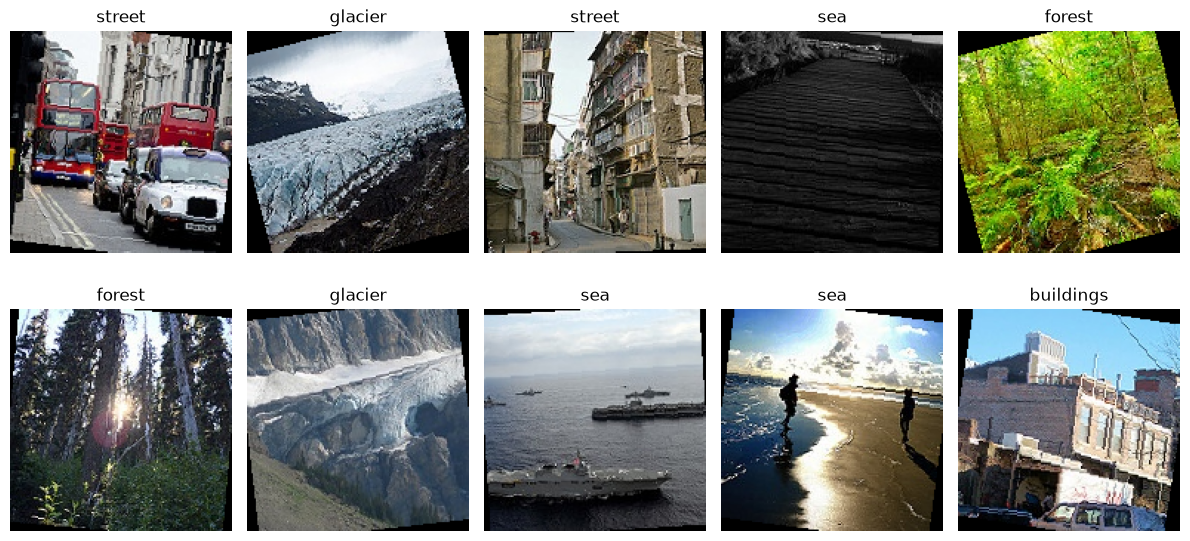

In [8]:
# Visualize a few training images

classes = train_dataset.classes
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    image = images[i]

    # Convert from (C,H,W) → (H,W,C)
    image = image.permute(1, 2, 0)

    # Undo normalization
    image = image * 0.5 + 0.5

    ax.imshow(image)
    ax.set_title(classes[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
#CNN Architecture
import torch.nn as nn

class IntelCNN(nn.Module):

    def __init__(self):
        super(IntelCNN,self).__init__()

        self.features=nn.Sequential(
            nn.Conv2d(3,32,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2)
        )

        self.classifier=nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*18*18,256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256,6)
        )

    def forward(self,x):
        x=self.features(x)
        x=self.classifier(x)
        return x


model=IntelCNN().to(device)
print(model)


IntelCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=41472, out_features=256, bias=True

In [10]:
#Check if the forward is working fine

images, labels = next(iter(train_loader))
# Forward pass
outputs = model(images)
print("Input Shape :", images.shape)
print("Output Shape :", outputs.shape)

Input Shape : torch.Size([64, 3, 150, 150])
Output Shape : torch.Size([64, 6])


In [11]:
#Loss Function and Optimizer
import torch.optim as optim

criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(
    model.parameters(),
    lr=0.001
)

In [12]:
#Training and Evaluating the model

def evaluate_model(model,test_loader,criterion):
    model.eval()

    running_loss=0.0
    correct=0
    total=0

    with torch.no_grad():

        for images,labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs=model(images)
            loss=criterion(outputs,labels)
            running_loss+=loss.item()

            _,predicted= torch.max(outputs,1)
            correct+=(predicted==labels).sum().item()
            total+=labels.size(0)

    epoch_loss = running_loss / len(test_loader)
    accuracy = 100 * correct / total

    print(f"Validation Loss : {epoch_loss:.4f}")
    print(f"Validation Accuracy : {accuracy:.2f}%")

    return epoch_loss, accuracy



def train_model(model,train_loader,test_loader,criterion,optimizer,epochs):

    best_accuracy=0.0

    train_accuracies=[]
    train_losses=[]
    val_losses=[]
    val_accuracies=[]

    for epoch in range(epochs):
        model.train()
        running_loss=0.0
        total=0
        correct=0

        for images,labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad() #resets the optimizer gradient furing backpropogation to 0 for every epoch

            #Forward Propogation
            outputs=model(images)
            #Calculate Train Accuracy
            _,predicted=torch.max(outputs,1)
            correct+=(predicted==labels).sum().item()
            total+=labels.size(0)
            #Calculate the Loss
            loss=criterion(outputs,labels)
            #Backpropogation
            loss.backward()
            #Update the Weights
            optimizer.step()
            running_loss+=loss.item()

        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)
        train_accuracy = 100 * correct / total
        train_accuracies.append(train_accuracy)
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {epoch_loss:.4f}")
        print(f"Training Accuracy : {train_accuracy:.2f}%")

        val_loss, val_accuracy = evaluate_model(
            model,
            test_loader,
            criterion
        )

        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        if val_accuracy > best_accuracy:

            best_accuracy = val_accuracy

            torch.save(
                model.state_dict(),
                "best_intel_cnn.pth"
            )

            print(f"✅ Best Model Saved! (Validation Accuracy: {best_accuracy:.2f}%)")

    print("\nTraining Completed!")
    print(f"Best Validation Accuracy: {best_accuracy:.2f}%")

    return train_accuracies,train_losses, val_losses, val_accuracies


In [13]:
#Train the  Model
train_accuracies,train_losses, val_losses, val_accuracies=train_model(model,train_loader,test_loader,criterion,optimizer,18)

Epoch [1/18] | Loss: 1.4900
Training Accuracy : 57.95%
Validation Loss : 0.8229
Validation Accuracy : 70.63%
✅ Best Model Saved! (Validation Accuracy: 70.63%)
Epoch [2/18] | Loss: 0.8621
Training Accuracy : 69.52%
Validation Loss : 0.6984
Validation Accuracy : 75.43%
✅ Best Model Saved! (Validation Accuracy: 75.43%)
Epoch [3/18] | Loss: 0.7535
Training Accuracy : 73.65%
Validation Loss : 0.6206
Validation Accuracy : 77.37%
✅ Best Model Saved! (Validation Accuracy: 77.37%)
Epoch [4/18] | Loss: 0.6903
Training Accuracy : 75.64%
Validation Loss : 0.5534
Validation Accuracy : 81.83%
✅ Best Model Saved! (Validation Accuracy: 81.83%)
Epoch [5/18] | Loss: 0.6570
Training Accuracy : 76.68%
Validation Loss : 0.8867
Validation Accuracy : 74.63%
Epoch [6/18] | Loss: 0.6073
Training Accuracy : 78.52%
Validation Loss : 0.5580
Validation Accuracy : 81.97%
✅ Best Model Saved! (Validation Accuracy: 81.97%)
Epoch [7/18] | Loss: 0.5779
Training Accuracy : 80.20%
Validation Loss : 0.5052
Validation Accur

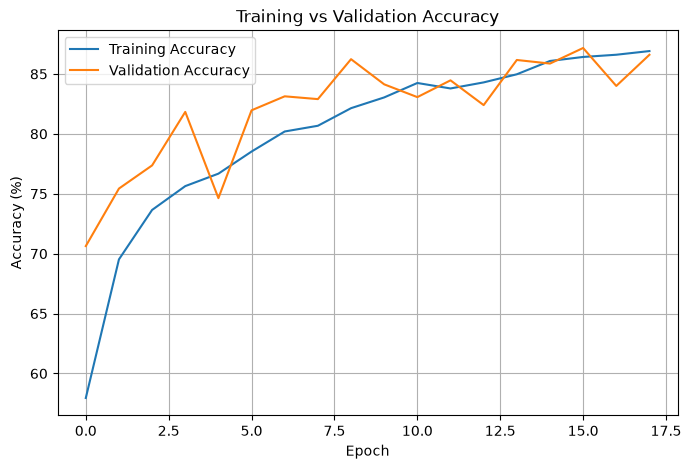

In [14]:
#Plot the Accuracy Graph
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

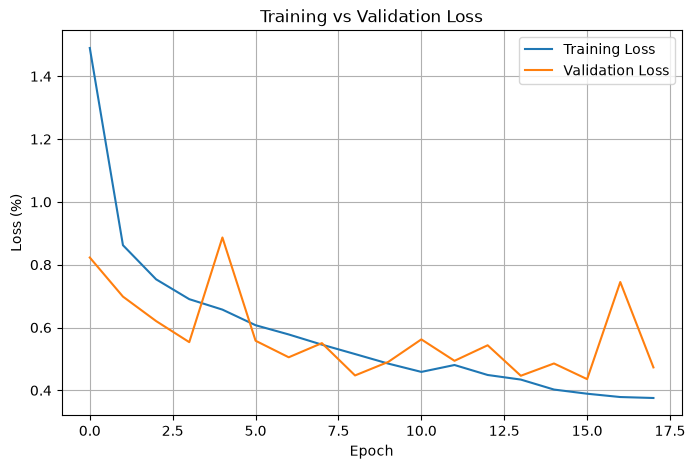

In [15]:
#Plot the Loss Graph
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss (%)")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()